# Deep Learning — CNN-1D y LSTM

**Objetivo:** Clasificar actividad humana alimentando la **señal cruda** directamente al modelo,  
sin extraer features manualmente. El modelo aprende sus propias representaciones.

**¿Por qué es distinto a los modelos clásicos?**
- RF/SVM: reciben 33 features que **nosotros** definimos (media, std, etc.)
- CNN/LSTM: reciben 90×3 valores crudos y **aprenden** qué patrones importan

Arquitecturas:
- **CNN-1D**: detecta patrones locales en la señal (como un filtro de paso de banda aprendido)
- **LSTM**: procesa la señal secuencialmente con memoria de timesteps anteriores

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from IPython.display import display
import pandas as pd

from src.data_loader import load_dataset, load_activity_labels
from src.evaluate import evaluate_model, plot_confusion_matrix
from src.models.deep import CNN1D, LSTMClassifier, train_epoch, eval_epoch, predict, save_model

FIGURES_DIR = Path('..') / 'figures'
MODELS_DIR  = Path('..') / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')
print(f'PyTorch version : {torch.__version__}')
print(f'Dispositivo     : {DEVICE}')

PyTorch version : 2.12.0
Dispositivo     : cpu


## 1. Dataset PyTorch y DataLoaders

PyTorch trabaja con `Dataset` (cómo acceder a los datos) y `DataLoader`  
(cómo iterar en batches). El shuffle en train evita que el modelo vea  
siempre los mismos ejemplos en el mismo orden (ayuda a generalizar).

In [2]:
class HARDataset(Dataset):
    """Dataset PyTorch para señales HAR."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


X_train, y_train = load_dataset('train')
X_test,  y_test  = load_dataset('test')
labels = load_activity_labels()

BATCH_SIZE = 256
train_ds = HARDataset(X_train, y_train)
test_ds  = HARDataset(X_test,  y_test)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=512,        shuffle=False, num_workers=0)

X_batch, y_batch = next(iter(train_loader))
print(f'Train: {len(train_ds):,} muestras  | Test: {len(test_ds):,} muestras')
print(f'Batch X: {X_batch.shape}  →  (batch_size, timesteps, canales)')
print(f'Batch y: {y_batch.shape}  →  clases: {y_batch.unique().tolist()}')

Train: 43,924 muestras  | Test: 10,982 muestras
Batch X: torch.Size([256, 90, 3])  →  (batch_size, timesteps, canales)
Batch y: torch.Size([256])  →  clases: [0, 1, 2, 3, 4, 5]


## 2. Función de entrenamiento

Loop estándar de entrenamiento en PyTorch: forward → loss → backward → step.  
El scheduler reduce la learning rate cada 10 epochs (facilita convergencia fina).

In [3]:
def run_training(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    n_epochs: int = 30,
    lr: float = 1e-3,
    model_name: str = 'model',
) -> dict:
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # StepLR: divide la LR por 2 cada 10 epochs
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(n_epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        va_loss, va_acc = eval_epoch(model,  test_loader,  criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{n_epochs} | '
                  f'Train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | '
                  f'Val   loss: {va_loss:.4f}  acc: {va_acc:.4f}')

    return history


def plot_history(history: dict, model_name: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title('Loss por epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy por epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.suptitle(f'Curvas de entrenamiento — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_').replace('-', '')
    plt.savefig(FIGURES_DIR / f'training_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


## 3. CNN-1D

**¿Cómo funciona una CNN-1D en señales temporales?**

Los filtros convolucionales detectan patrones locales en la señal.  
Un filtro de tamaño 5 ve 5 timesteps consecutivos y aprende a detectar,  
por ejemplo, el pico de impacto de un paso o la periodicidad del jogging.

MaxPool1d reduce la longitud temporal a la mitad, haciendo el modelo  
más robusto a pequeños desplazamientos temporales (invarianza a traslación).

**Arquitectura:**
```
Input (batch, 90, 3) → permute → (batch, 3, 90)
Conv1d(3→64, k=5) → BN → ReLU → MaxPool → (batch, 64, 45)
Conv1d(64→128, k=5) → BN → ReLU → MaxPool → (batch, 128, 22)
Flatten → (batch, 2816)
FC(2816→128) → ReLU → Dropout → FC(128→6)
```

In [4]:
cnn = CNN1D(n_channels=3, n_classes=6, n_timesteps=90)
n_params_cnn = sum(p.numel() for p in cnn.parameters())
print(f'CNN-1D — parámetros entrenables: {n_params_cnn:,}')
print(cnn)

CNN-1D — parámetros entrenables: 403,846
CNN1D(
  (conv_block1): Sequential(
    (0): Conv1d(3, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2816, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [5]:
print('Entrenando CNN-1D (30 epochs)...')
history_cnn = run_training(cnn, train_loader, test_loader, n_epochs=30, model_name='CNN-1D')

Entrenando CNN-1D (30 epochs)...
Epoch   5/30 | Train loss: 0.1748  acc: 0.9415 | Val   loss: 0.1232  acc: 0.9568
Epoch  10/30 | Train loss: 0.1228  acc: 0.9582 | Val   loss: 0.0936  acc: 0.9682
Epoch  15/30 | Train loss: 0.0911  acc: 0.9680 | Val   loss: 0.0696  acc: 0.9781
Epoch  20/30 | Train loss: 0.0815  acc: 0.9715 | Val   loss: 0.0632  acc: 0.9808
Epoch  25/30 | Train loss: 0.0661  acc: 0.9777 | Val   loss: 0.0575  acc: 0.9828
Epoch  30/30 | Train loss: 0.0631  acc: 0.9785 | Val   loss: 0.0552  acc: 0.9826


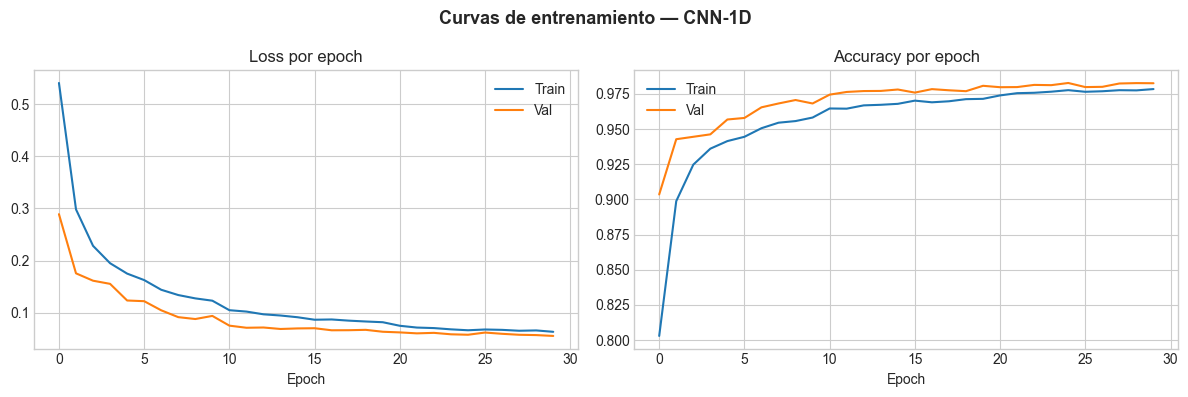


  CNN-1D
  Accuracy:    0.9826
  F1-macro:    0.9746
  F1-weighted: 0.9826

              precision    recall  f1-score   support

     Walking       0.94      0.95      0.94      1013
     Jogging       0.99      0.99      0.99      3481
     Sitting       0.99      0.98      0.99       596
    Standing       0.98      1.00      0.99       482
    Upstairs       0.95      0.94      0.94      1173
  Downstairs       0.99      0.99      0.99      4237

    accuracy                           0.98     10982
   macro avg       0.97      0.98      0.97     10982
weighted avg       0.98      0.98      0.98     10982

CNN-1D guardada.


In [6]:
plot_history(history_cnn, 'CNN-1D')

y_pred_cnn = predict(cnn, test_loader, DEVICE)
metrics_cnn = evaluate_model(y_test, y_pred_cnn, labels, 'CNN-1D')

np.save(MODELS_DIR / 'cnn_preds.npy', y_pred_cnn)
save_model(cnn, 'cnn1d')
print('CNN-1D guardada.')

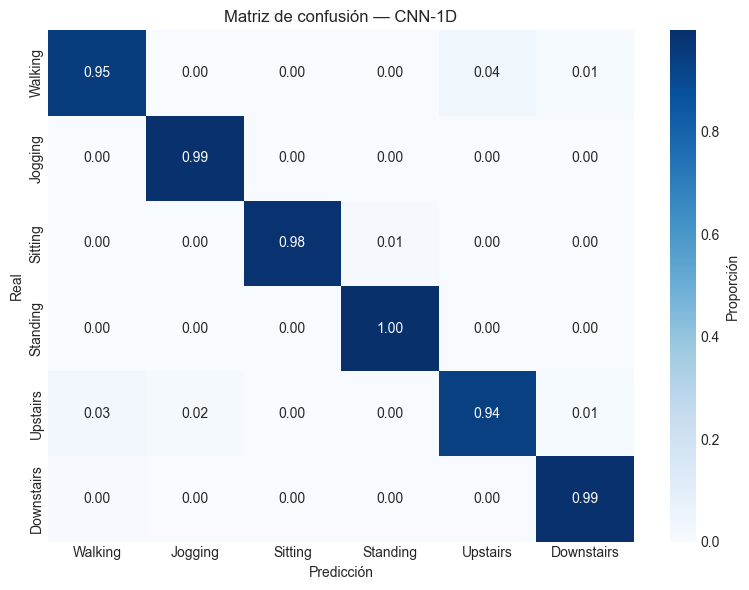

In [7]:
plot_confusion_matrix(y_test, y_pred_cnn, labels, 'CNN-1D')

## 4. LSTM

**¿Cómo funciona el LSTM?**

A diferencia de la CNN que ve ventanas locales, el LSTM procesa la señal timestep a timestep manteniendo un **estado oculto** que actúa como memoria.  
Esto le permite capturar dependencias a largo plazo en la secuencia.

Para clasificación, usamos el estado oculto del **último timestep** como representación de toda la secuencia, y lo pasamos a un clasificador FC.

**Arquitectura:**
```
Input (batch, 90, 3)
LSTM(3 → 128, 2 capas, dropout=0.3)
Tomar último timestep → (batch, 128)
FC(128→64) → ReLU → Dropout → FC(64→6)
```

In [8]:
lstm = LSTMClassifier(n_features=3, n_classes=6, hidden_size=128, n_layers=2)
n_params_lstm = sum(p.numel() for p in lstm.parameters())
print(f'LSTM — parámetros entrenables: {n_params_lstm:,}')
print(lstm)

LSTM — parámetros entrenables: 208,838
LSTMClassifier(
  (lstm): LSTM(3, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [9]:
print('Entrenando LSTM (30 epochs)...')
history_lstm = run_training(lstm, train_loader, test_loader, n_epochs=30, model_name='LSTM')

Entrenando LSTM (30 epochs)...
Epoch   5/30 | Train loss: 0.3577  acc: 0.8637 | Val   loss: 0.3117  acc: 0.8801
Epoch  10/30 | Train loss: 0.2238  acc: 0.9191 | Val   loss: 0.2139  acc: 0.9235
Epoch  15/30 | Train loss: 0.1253  acc: 0.9592 | Val   loss: 0.1248  acc: 0.9590
Epoch  20/30 | Train loss: 0.0843  acc: 0.9737 | Val   loss: 0.0851  acc: 0.9724
Epoch  25/30 | Train loss: 0.0542  acc: 0.9834 | Val   loss: 0.0783  acc: 0.9772
Epoch  30/30 | Train loss: 0.0454  acc: 0.9864 | Val   loss: 0.0734  acc: 0.9773


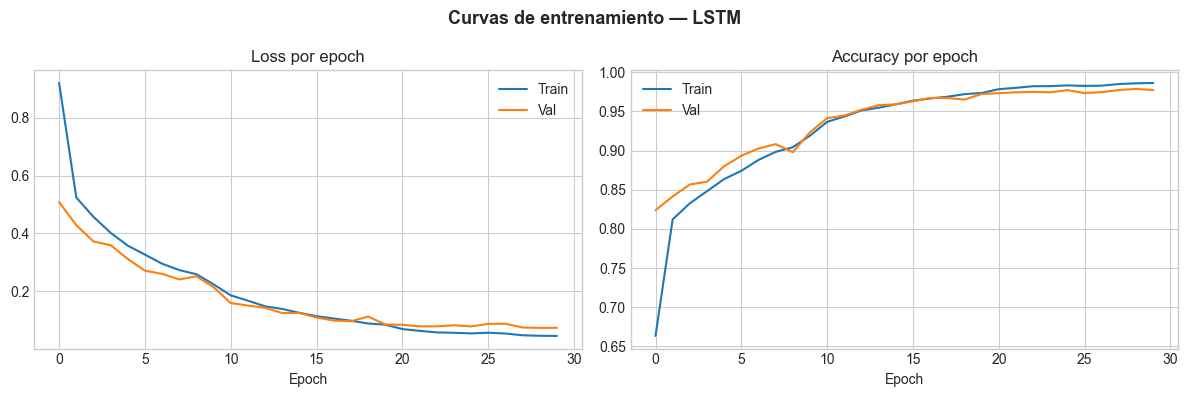


  LSTM
  Accuracy:    0.9773
  F1-macro:    0.9686
  F1-weighted: 0.9774

              precision    recall  f1-score   support

     Walking       0.93      0.92      0.93      1013
     Jogging       0.99      0.99      0.99      3481
     Sitting       1.00      0.98      0.99       596
    Standing       0.98      1.00      0.99       482
    Upstairs       0.91      0.95      0.93      1173
  Downstairs       0.99      0.99      0.99      4237

    accuracy                           0.98     10982
   macro avg       0.97      0.97      0.97     10982
weighted avg       0.98      0.98      0.98     10982

LSTM guardado.


In [10]:
plot_history(history_lstm, 'LSTM')

y_pred_lstm = predict(lstm, test_loader, DEVICE)
metrics_lstm = evaluate_model(y_test, y_pred_lstm, labels, 'LSTM')

np.save(MODELS_DIR / 'lstm_preds.npy', y_pred_lstm)
save_model(lstm, 'lstm')
print('LSTM guardado.')

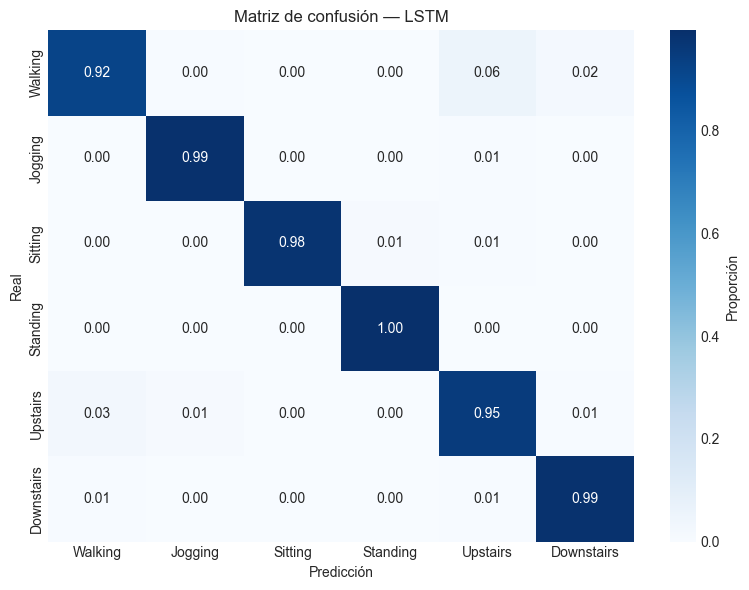

In [11]:
plot_confusion_matrix(y_test, y_pred_lstm, labels, 'LSTM')

## 5. Comparativa CNN-1D vs LSTM

=== DEEP LEARNING — COMPARATIVA ===


,Params,accuracy,f1_macro,f1_weighted
Modelo,,,,
CNN-1D,"403,846",0.9826,0.9746,0.9826
LSTM,"208,838",0.9773,0.9686,0.9774


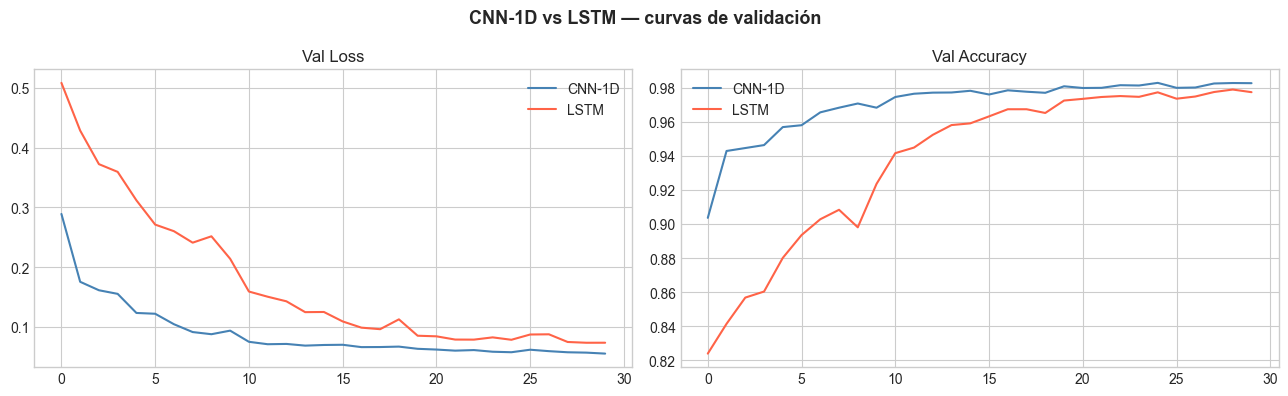

In [12]:
from sklearn.metrics import f1_score

results_dl = pd.DataFrame([
    {'Modelo': 'CNN-1D', 'Params': f'{n_params_cnn:,}', **metrics_cnn},
    {'Modelo': 'LSTM',   'Params': f'{n_params_lstm:,}', **metrics_lstm},
]).set_index('Modelo')

print('=== DEEP LEARNING — COMPARATIVA ===')
display(results_dl.round(4))

# Curvas comparativas
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hist, name, color in [(history_cnn, 'CNN-1D', 'steelblue'), (history_lstm, 'LSTM', 'tomato')]:
    axes[0].plot(hist['val_loss'], label=name, color=color)
    axes[1].plot(hist['val_acc'],  label=name, color=color)

axes[0].set_title('Val Loss')
axes[0].legend()
axes[1].set_title('Val Accuracy')
axes[1].legend()
plt.suptitle('CNN-1D vs LSTM — curvas de validación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_vs_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusiones — Deep Learning

- Ambas redes aprenden de la **señal cruda** sin necesidad de features manuales.
- **CNN-1D** es más rápida de entrenar (convolución paralelizable) y generalmente converge antes.
- **LSTM** captura dependencias temporales largas pero es más lenta y puede sufrir más overfitting.
- El principal desafío sigue siendo **Sitting vs Standing** — incluso DL tiene dificultades porque la señal estática no tiene patrones temporales ricos.

**Para defender ante el profesor:**
- ¿Por qué usás señal cruda en DL y no features estadísticas? → Las redes aprenden representaciones óptimas para la tarea. Features manuales introducen sesgo humano.
- ¿Por qué CNN-1D y no solo LSTM? → CNN detecta patrones locales (invarianza a traslación); LSTM captura dependencias largas. Son complementarios.
- ¿Qué hace el Dropout? → Técnica de regularización: apaga neuronas aleatorias durante entrenamiento para evitar co-adaptación y overfitting.
- ¿Qué es el BatchNorm? → Normaliza las activaciones de cada capa durante el entrenamiento → acelera convergencia y estabiliza el gradiente.